In [1]:
import fastf1 as ff1
import fastf1.plotting
import seaborn as sns
from matplotlib import pyplot as plt

%matplotlib widget

ff1.plotting.setup_mpl(mpl_timedelta_support=True, color_scheme="fastf1")

In [2]:
race = ff1.get_session(2025, 23, "R")
race.load()

req         WARNING 	DEFAULT CACHE ENABLED! (611.82 MB) C:\Users\Vitor\AppData\Local\Temp\fastf1


core           INFO 	Loading data for Qatar Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '55', '4', '12', '63', '14', '16', '30', '22', '23', '44', '5', '43', '31', '10', '18', '6', '87', '27']


In [3]:
driver_laps = race.laps.pick_drivers("VER").pick_quicklaps().reset_index()

<Axes: xlabel='LapNumber', ylabel='LapTime'>

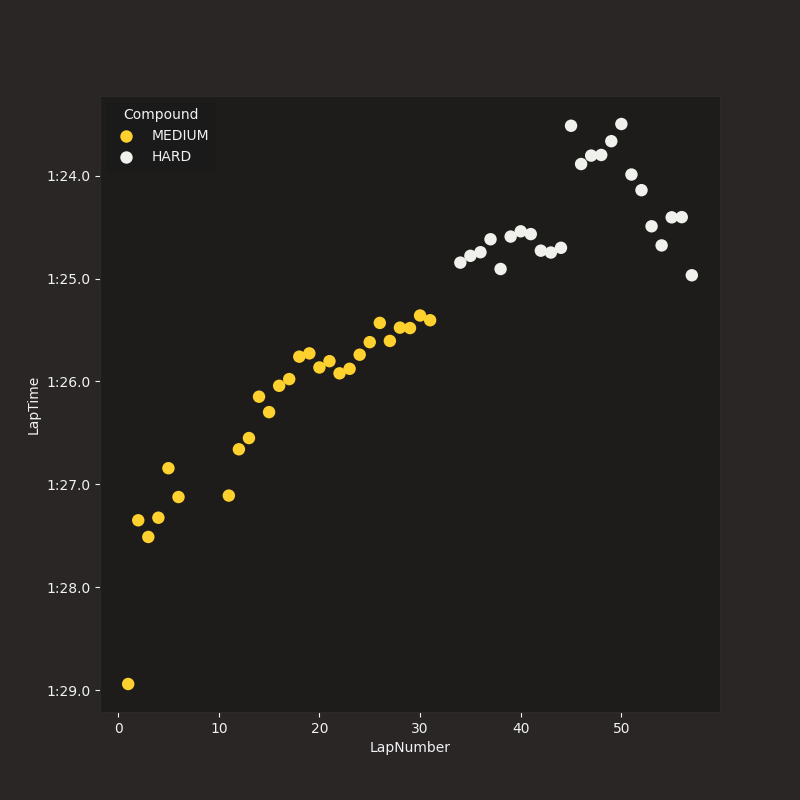

In [4]:
fig, ax = plt.subplots(figsize=(8, 8))

sns.scatterplot(data=driver_laps,
                x="LapNumber",
                y="LapTime",
                ax=ax,
                hue="Compound",
                palette=ff1.plotting.get_compound_mapping(session=race),
                s=80,
                linewidth=0,
                legend="auto")

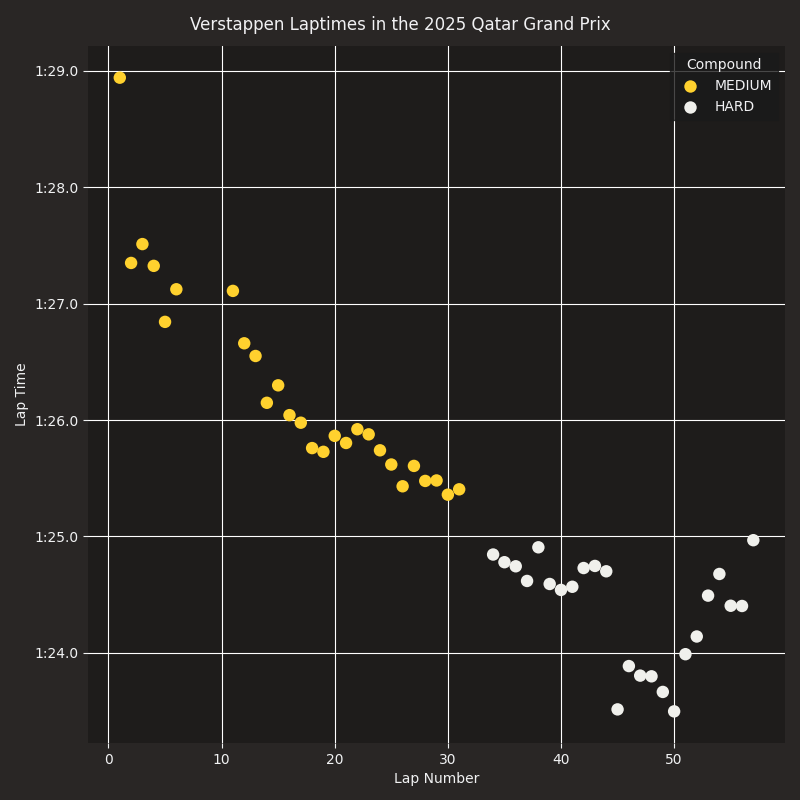

In [5]:
ax.set_xlabel("Lap Number")
ax.set_ylabel("Lap Time")

# The y-axis increases from bottom to top by default
# Since we are plotting time, it makes sense to invert the axis
ax.invert_yaxis()
plt.suptitle("Verstappen Laptimes in the 2025 Qatar Grand Prix")

# Turn on major grid lines
plt.grid(color="w", which="major", axis="both")
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()